# Deep learning project

This is a deep learning project established by Guillaume, Talib, and Cédric Manelli. The goal of this project is to build and compare deep learning models to automatically classify colorectal cancer histology images into nine tissue types.

## Data and library importation 

In [61]:
#pip install medmnist
from medmnist import PathMNIST

## 1) Data exploration
Importation of the dataset from medmnist library and exploration of them. 

In [62]:
from medmnist import INFO

data_flag = "pathmnist"
info = INFO[data_flag]

print(info)

{'python_class': 'PathMNIST', 'description': 'The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test set.', 'url': 'https://zenodo.org/records/10519652/files/pathmnist.npz?download=1', 'MD5': 'a8b06965200029087d5bd730944a56c1', 'url_64': 'https://zenodo.org/records/10519652/files/pathmnist_64.npz?download=1', 'MD5_64': '55aa9c1e0525abe5a6b9d8343a507616', 'url_128': 'https://zenodo.org/records/10519652/files/pathmnist_128.npz?download=1', 'MD5_128': 

Let separate dataset to a cohorte for the deep learning project. The dataset have an initialized cohorte with train, val and test.

In [63]:
train = PathMNIST(split="train", download=True)
val = PathMNIST(split="val", download=True)
test = PathMNIST(split="test", download=True)

Use the train dataset to analyse images and get informations

In [64]:
train_images = train.imgs
train_labels = train.labels

In [65]:
# get image shape
train_images.shape

(89996, 28, 28, 3)

It's ineresting to explore all of classes. We have 9 classes '0' adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'

C:\Users\MANEL\AppData\Local\Temp\ipykernel_17332\854996401.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(label)


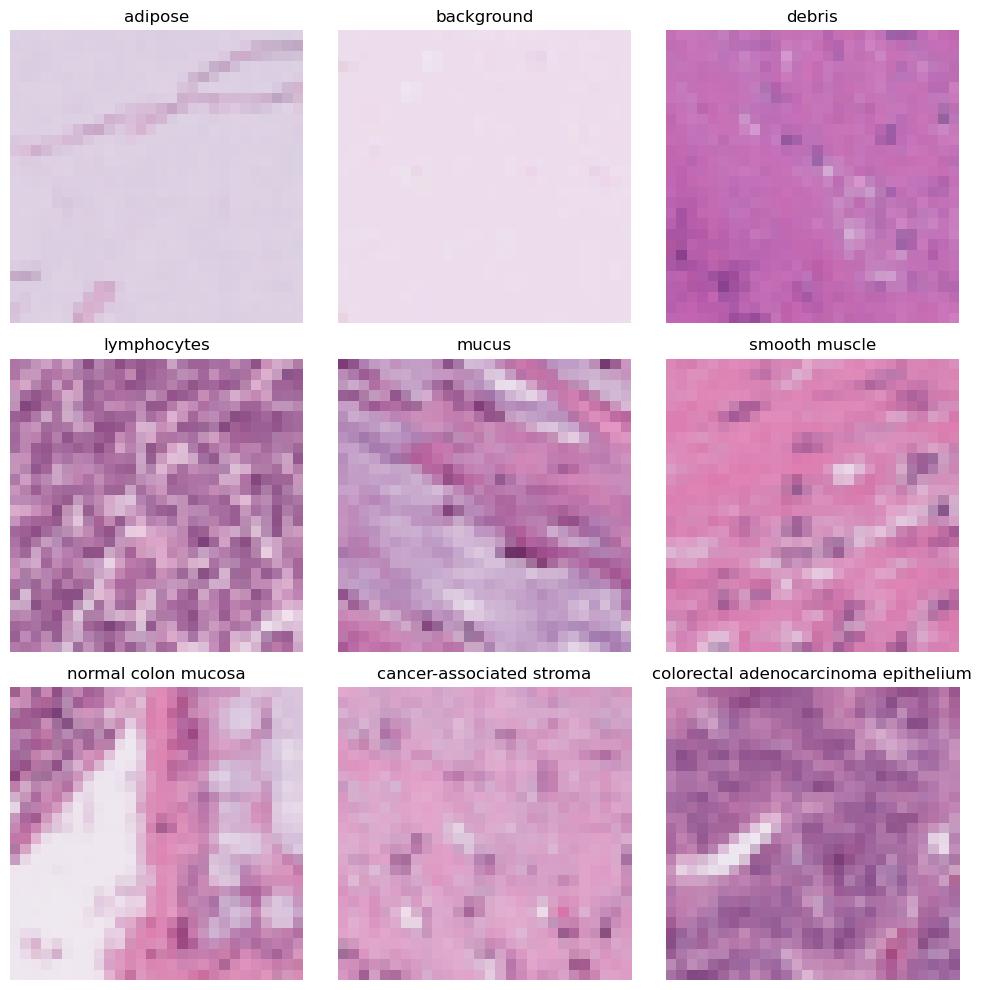

In [66]:

# Display one image per class
import matplotlib.pyplot as plt

num_classes = 9
class_images = [None] * num_classes
# find one image per class
for img, label in zip(train_images, train_labels):
    label = int(label)
    if class_images[label] is None:
        class_images[label] = img
    if all(x is not None for x in class_images):
        break

labels_names = info["label"]

# plot the images
plt.figure(figsize=(10,10))

for i in range(num_classes):
    plt.subplot(3,3,i+1)
    plt.imshow(class_images[i])
    plt.title(labels_names.get(str(i)))
    plt.axis("off")

plt.tight_layout()
plt.show()

Look at several images from the 'debris' class and several from 'background' class

C:\Users\MANEL\AppData\Local\Temp\ipykernel_17332\4231178817.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(label)


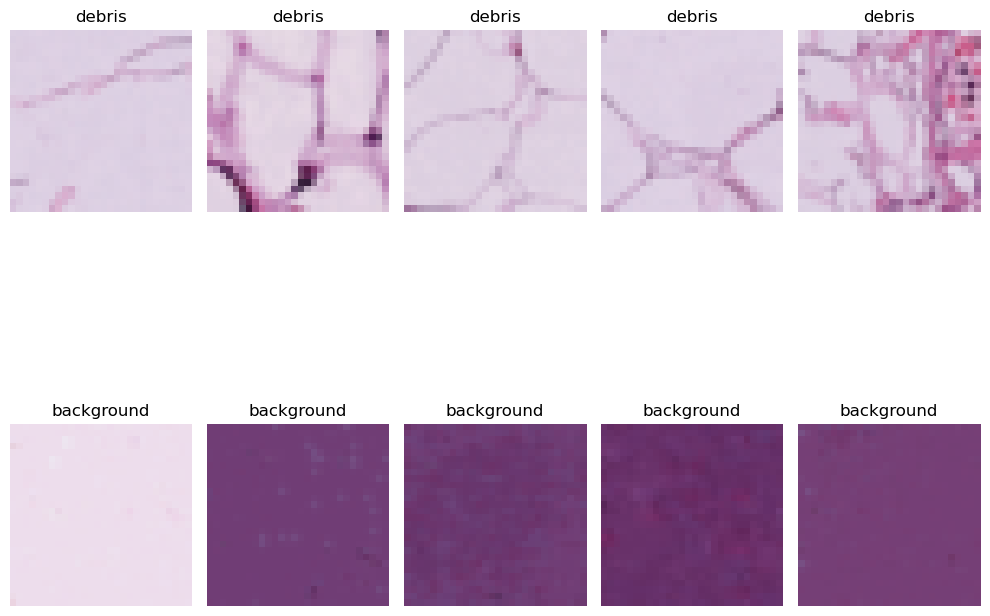

In [67]:
# look several images of the class "debris" and the class "background"
debris_images = []
background_images = []
i=0
j=0
for img, label in zip(train_images, train_labels):
    label = int(label)
    if label == 0:
        debris_images.append(img)
        i += 1
    elif label == 1:
        background_images.append(img)
        j += 1
    if i == 5 and j == 5:
        break
# plot the images
plt.figure(figsize=(10,10))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(debris_images[i])
    plt.title("debris")
    plt.axis("off")
for i in range(5):
    plt.subplot(2, 5, i+6)
    plt.imshow(background_images[i])
    plt.title("background")
    plt.axis("off")
plt.tight_layout()
plt.show()

**Debris :** 

* Visible structures and edges
* Thin irregular lines or fibrous patterns like web
* Texture looks heterogeneous

In several images we can see web-like or branching shapes.

**Background:**

* Mostly uniform color
* No visible biological structures
* Very smooth texture
* Looks like empty slide regions

These tiles look almost flat. Some are nearly monochrome purple with slight noise.

7


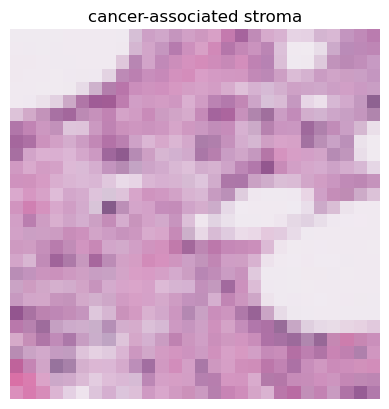

In [76]:
# pick any image from training dataset display it
import numpy as np
#pick an image
random_number = np.random.randint(0, len(train_images))
image_rdm = train_images[random_number]
label_rdm = train_labels[random_number]
print(label_rdm[0])
# display the image
plt.imshow(image_rdm)
plt.axis("off")
plt.title(labels_names.get(str(label_rdm[0])))
plt.show()

In [84]:
# report the pixel intensity statistics: mean and standard deviation per channel
means = np.mean(image_rdm, axis=(0,1))
stds = np.std(image_rdm, axis=(0,1))
print("Mean per channel:", means)
print("Standard deviation per channel:", stds)

Mean per channel: [208.95280612 168.35331633 201.29081633]
Standard deviation per channel: [20.2567466  37.14534901 23.14714725]


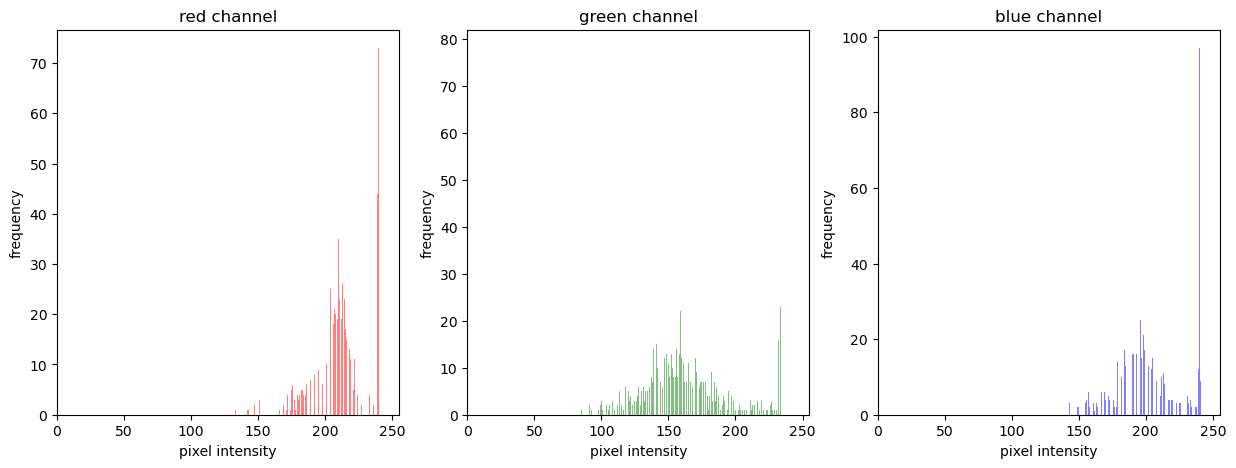

In [79]:
# plot the histogram of pixel intensities for each channel
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(image_rdm[:,:,0].flatten(), bins=256, color='red', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("red channel")
plt.subplot(1,3,2)
plt.hist(image_rdm[:,:,1].flatten(), bins=256, color='green', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("green channel")
plt.subplot(1,3,3)
plt.hist(image_rdm[:,:,2].flatten(), bins=256, color='blue', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("blue channel")
plt.show()

mean: [188.83897503 135.91045926 179.98635682]
std: [31.53896524 45.07444572 31.72982184]


Value with normalisation
mean normalized: [0.740545   0.53298219 0.70582885]
std normalized: [0.12368222 0.17676253 0.12443067]


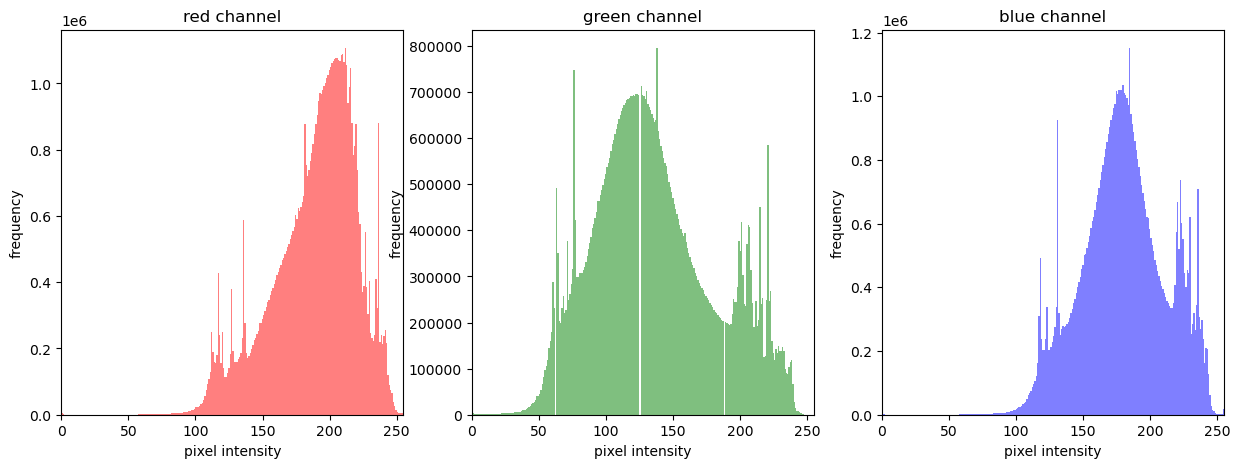

In [86]:
# generelyze for all the images in the training dataset.
mean = np.mean(train_images, axis=(0,1,2))
std = np.std(train_images, axis=(0,1,2))
print("mean:", mean)
print("std:", std)
mean_norm = mean / 255.0
std_norm = std / 255.0
print("\n")
print("Value with normalisation")
print("mean normalized:", mean_norm)
print("std normalized:", std_norm)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(train_images[:,:,:,0].flatten(), bins=256, color='red', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("red channel")
plt.subplot(1,3,2)
plt.hist(train_images[:,:,:,1].flatten(), bins=256, color='green', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("green channel")
plt.subplot(1,3,3)
plt.hist(train_images[:,:,:,2].flatten(), bins=256, color='blue', alpha=0.5)
plt.xlabel("pixel intensity")
plt.ylabel("frequency")
plt.xlim(0, 255)
plt.title("blue channel")
plt.show()

The mean and standard deviation of pixel intensities were computed for a randomly selected training image. The obtained values were approximately mean = [188.8, 135.9, 180.0] and standard deviation = [31.5, 45.1, 31.7] in the [0,255] range. When rescaled to the [0,1] range, the mean values are around [0.74, 0.53, 0.71] and the standard deviations around [0.12, 0.18, 0.12]. These statistics differ from the commonly used normalization values derived from ImageNet (mean ≈ [0.485, 0.456, 0.406], std ≈ [0.229, 0.224, 0.225]). This difference is expected because histology images exhibit characteristic color distributions caused by hematoxylin–eosin staining, resulting in dominant pink and purple tones. Consequently, ImageNet normalization may not be optimal for this dataset, and it is preferable to compute dataset-specific statistics across the entire training set before training the convolutional neural network.